# Train LightGB

### Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
from datetime import datetime, timedelta
import lightgbm as lgb
import joblib
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from typing import cast
import numpy.typing as npt

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import sys

root_path = Path.cwd().parent.parent
sys.path.append(str(root_path))

# personalized imports
from scripts.data_preparation.get_main import main_query_db
from scripts.data_preparation.preprocessed import main_preprocessed
from scripts.data_preparation.utils.progress_bar import TqdmCallback

### Global variables

In [2]:
root = Path(os.getcwd()).parent.parent
DATA_FOLDER_PATH = os.path.join(root, "data")

DATASET_PATH_PAX = os.path.join(DATA_FOLDER_PATH, "main_preprocessed.csv")
DATASET_PATH_PHMR = os.path.join(DATA_FOLDER_PATH, "main_preprocessed_PHMR.csv")

MODEL_FOLDER_PATH = os.path.join(root, "models")
MODEL_FILENAME = os.path.join(MODEL_FOLDER_PATH, "lgbm_regressor.pkl")
MODEL_FILENAME_PHMR = os.path.join(MODEL_FOLDER_PATH, "lgbm_regressor_PHMR.pkl")

TARGET = ["NbPaxTotal", "FarmsNbPaxPHMR"]

# Today & tomorrow
now = datetime.now()
today = pd.Timestamp(now.date())
yesterday =  pd.Timestamp(today - timedelta(days=1))
two_days = pd.Timestamp(yesterday - timedelta(days=1))
tomorrow = pd.Timestamp(today + timedelta(days=1))

# LIMIT_DATE_TRAIN = two_days
# LIMIT_DATE_VALID = yesterday
# LIMIT_DATE_TEST = today


LIMIT_DATE_TRAIN = pd.Timestamp("2026-03-27")
LIMIT_DATE_VALID = pd.Timestamp("2026-03-28")
LIMIT_DATE_TEST = pd.Timestamp("2026-03-30")


PREDICTIONS_FILENAME = os.path.join(DATA_FOLDER_PATH, f"prediction_{LIMIT_DATE_VALID.strftime('%Y-%m-%d')}.csv")

### Load and prepare data

In [ ]:
# Load the preprocessed data - or build the needed df.
if os.path.exists(DATASET_PATH_PAX) and os.path.exists(DATASET_PATH_PHMR) : 
    print('Loading preprocessed file ...')
    df = pd.read_csv(DATASET_PATH_PAX, encoding='utf-8')
    df_PHMR = pd.read_csv(DATASET_PATH_PHMR, encoding='utf-8')
else:
    ### Full pipeline
    # Query the data
    # Using BigQuery.
    print("Querying ...")
    main_query_db()
    print("Preprocessing ...")
    df, df_PHMR = main_preprocessed()

Querying ...
Preprocessing ...


#### Data splitting

In [5]:
### PAX
df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'])

train_df = df[df['LTScheduledDatetime'] < LIMIT_DATE_TRAIN].copy()
valid_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_TRAIN) & (df['LTScheduledDatetime'] < LIMIT_DATE_VALID)].copy()
test_df = df[(df['LTScheduledDatetime'] >= LIMIT_DATE_VALID) & (df['LTScheduledDatetime'] <= LIMIT_DATE_TEST)].copy()

print(f"Train set: {len(train_df)} rows / From {train_df['LTScheduledDatetime'].min()} to {train_df['LTScheduledDatetime'].max()}")
print(f"Valid set: {len(valid_df)} rows / From {valid_df['LTScheduledDatetime'].min()} to {valid_df['LTScheduledDatetime'].max()}")
print(f"Test set: {len(test_df)} rows / From {test_df['LTScheduledDatetime'].min()} to {test_df['LTScheduledDatetime'].max()}")

### PHMR
df_PHMR['LTScheduledDatetime'] = pd.to_datetime(df_PHMR['LTScheduledDatetime'])

train_df_PHMR = df_PHMR[df_PHMR['LTScheduledDatetime'] < LIMIT_DATE_TRAIN].copy()
valid_df_PHMR = df_PHMR[(df_PHMR['LTScheduledDatetime'] >= LIMIT_DATE_TRAIN) & (df_PHMR['LTScheduledDatetime'] < LIMIT_DATE_VALID)].copy()
test_df_PHMR = df_PHMR[(df_PHMR['LTScheduledDatetime'] >= LIMIT_DATE_VALID) & (df_PHMR['LTScheduledDatetime'] <= LIMIT_DATE_TEST)].copy()

print(f"Train set PHMR: {len(train_df_PHMR)} rows / From {train_df_PHMR['LTScheduledDatetime'].min()} to {train_df_PHMR['LTScheduledDatetime'].max()}")
print(f"Valid set PHMR: {len(valid_df_PHMR)} rows / From {valid_df_PHMR['LTScheduledDatetime'].min()} to {valid_df_PHMR['LTScheduledDatetime'].max()}")
print(f"Test set PHMR: {len(test_df_PHMR)} rows / From {test_df_PHMR['LTScheduledDatetime'].min()} to {test_df_PHMR['LTScheduledDatetime'].max()}")


Train set: 308871 rows / From 2023-01-01 00:05:00 to 2026-03-26 23:45:00
Valid set: 284 rows / From 2026-03-27 04:45:00 to 2026-03-27 23:55:00
Test set: 510 rows / From 2026-03-28 05:10:00 to 2026-03-29 23:50:00
Train set PHMR: 308871 rows / From 2023-01-01 00:05:00 to 2026-03-26 23:45:00
Valid set PHMR: 284 rows / From 2026-03-27 04:45:00 to 2026-03-27 23:55:00
Test set PHMR: 510 rows / From 2026-03-28 05:10:00 to 2026-03-29 23:50:00


#### Last preprocess

In [6]:
### PAX
# re-conversion in str mandatory to be able to train the model. Note that keep this variable is mandatory.
train_df['LTScheduledDatetime'] = train_df['LTScheduledDatetime'].astype(str)
valid_df['LTScheduledDatetime'] = valid_df['LTScheduledDatetime'].astype(str)
test_df['LTScheduledDatetime'] = test_df['LTScheduledDatetime'].astype(str)

# Slice X, y
X_train = train_df.drop(columns=[TARGET[0]])
y_train = train_df[TARGET[0]]
X_valid = valid_df.drop(columns=[TARGET[0]])
y_valid = valid_df[TARGET[0]]
X_test = test_df.drop(columns=[TARGET[0]])

# Convert to categorical the needed features.
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
    X_valid[col] = X_valid[col].astype('category')
    X_test[col] = X_test[col].astype('category')


print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_valid: {X_valid.shape}")
print(f"Shape X_test: {X_test.shape}")

### PHMR
# re-conversion in str mandatory to be able to train the model. Note that keep this variable is mandatory.
train_df_PHMR['LTScheduledDatetime'] = train_df_PHMR['LTScheduledDatetime'].astype(str)
valid_df_PHMR['LTScheduledDatetime'] = valid_df_PHMR['LTScheduledDatetime'].astype(str)
test_df_PHMR['LTScheduledDatetime'] = test_df_PHMR['LTScheduledDatetime'].astype(str)

# Slice X, y
X_train_PHMR = train_df_PHMR.drop(columns=[TARGET[1]])
y_train_PHMR = train_df_PHMR[TARGET[1]]
X_valid_PHMR = valid_df_PHMR.drop(columns=[TARGET[1]])
y_valid_PHMR = valid_df_PHMR[TARGET[1]]
X_test_PHMR = test_df_PHMR.drop(columns=[TARGET[1]])

# Convert to categorical the needed features.
for col in X_train_PHMR.select_dtypes(include=['object']).columns:
    X_train_PHMR[col] = X_train_PHMR[col].astype('category')
    X_valid_PHMR[col] = X_valid_PHMR[col].astype('category')
    X_test_PHMR[col] = X_test_PHMR[col].astype('category')


print(f"Shape X_train_PHMR: {X_train_PHMR.shape}")
print(f"Shape X_valid_PHMR: {X_valid_PHMR.shape}")
print(f"Shape X_test_PHMR: {X_test_PHMR.shape}")


Shape X_train: (308871, 596)
Shape X_valid: (284, 596)
Shape X_test: (510, 596)
Shape X_train_PHMR: (308871, 30)
Shape X_valid_PHMR: (284, 30)
Shape X_test_PHMR: (510, 30)


In [ ]:
### Remove the less important features.
# this feature_importance.csv dataset is obtained by training the model once with all the features . Here to save time, we first remove the useless features to test the model performances with the new set of features.
# importance = pd.read_csv(os.path.join(DATA_PATH, 'feature_importance.csv'), encoding='utf-8')
# col_to_rmv_list = importance["feature"].tail(500).tolist()

# df = df.drop(columns=col_to_rmv_list)

### Train or Load the model

#### 1. Pax train

In [21]:
# Check if there is an existing model.
if os.path.exists(MODEL_FILENAME) :
    model_Pax = joblib.load(MODEL_FILENAME)
    print("Pax model load successfuly.")

else : 
    n_estimators = 10000

    model_Pax = lgb.LGBMRegressor(
        objective="regression",      
        n_estimators=n_estimators,      
        learning_rate=0.01,
        num_leaves=255,               
        min_child_samples=5,
        feature_fraction=0.8,
        random_state=42,
        verbose=-1
    )

    tqdm_callback = TqdmCallback(total=n_estimators)
    try:
        model_Pax.fit(
            X_train, y_train,         
            eval_set=[(X_valid, y_valid)], 
            eval_metric="mae",
            callbacks=[
                lgb.early_stopping(100),
                tqdm_callback 
            ]
        )
    finally:
        tqdm_callback.pbar.close()

    joblib.dump(model_Pax, MODEL_FILENAME)

LightGBM training:   0%|          | 1/10000 [00:20<56:46:49, 20.44s/it, mae=58.5457]

Training until validation scores don't improve for 100 rounds


LightGBM training:  10%|█         | 1019/10000 [12:10<1:29:37,  1.67it/s, mae=11.6608]

Early stopping, best iteration is:
[919]	valid_0's l1: 11.6565	valid_0's l2: 294.452


LightGBM training:  10%|█         | 1019/10000 [12:14<1:47:49,  1.39it/s, mae=11.6608]


#### 2. PHMR Train

In [22]:
# Check if there is an existing model.
if os.path.exists(MODEL_FILENAME_PHMR) :  
    model_PHMR = joblib.load(MODEL_FILENAME_PHMR)
    print("PHMR model load successfuly.")

else : 
    n_estimators = 10000

    model_PHMR = lgb.LGBMRegressor(
        objective="regression",      
        n_estimators=n_estimators,      
        learning_rate=0.01,
        num_leaves=255,               
        min_child_samples=5,
        feature_fraction=0.8,
        random_state=42,
        verbose=-1
    )

    tqdm_callback = TqdmCallback(total=n_estimators)
    try:
        model_PHMR.fit(
            X_train_PHMR, y_train_PHMR,         
            eval_set=[(X_valid_PHMR, y_valid_PHMR)], 
            eval_metric="mae",
            callbacks=[
                lgb.early_stopping(100),
                tqdm_callback 
            ]
        )
    finally:
        tqdm_callback.pbar.close()

    joblib.dump(model_PHMR, MODEL_FILENAME_PHMR)

PHMR model load successfuly.


### Prediction and Evaluation

#### Evaluation on the validation dataset

- PAX :

In [35]:
predictions = model_Pax.predict(X_valid)
preds_array = cast(npt.NDArray[np.float32], predictions)
predictions = np.maximum(0.0, preds_array)

mae = mean_absolute_error(y_valid, predictions)
r2 = r2_score(y_valid, predictions)
rmse = root_mean_squared_error(y_valid, predictions)

print(f"\n── Results for Pax model ──")
print(f"   MAE : {mae:.2f} passengers")    
print(f"   R²  : {r2:.4f}")
print(f"   RMSE : {rmse:.2f}")


── Results for Pax model ──
   MAE : 11.61 passengers
   R²  : 0.9345
   RMSE : 17.16


- PHMR

In [36]:
predictions_PHMR = model_PHMR.predict(X_valid_PHMR)
preds_array = cast(npt.NDArray[np.float32], predictions_PHMR)
predictions_PHMR = np.maximum(0.0, preds_array)

mae = mean_absolute_error(y_valid_PHMR, predictions_PHMR)
r2 = r2_score(y_valid_PHMR, predictions_PHMR)
rmse = root_mean_squared_error(y_valid_PHMR, predictions_PHMR)

print(f"\n── Results for PHMR models ──")
print(f"   MAE : {mae:.2f} passengers")    
print(f"   R²  : {r2:.4f}")
print(f"   RMSE : {rmse:.2f}")


── Results for PHMR models ──
   MAE : 0.35 passengers
   R²  : 0.7276
   RMSE : 1.22


#### Predictions

In [29]:
# predictions
predictions_nb_pax = model_Pax.predict(X_test)
preds_nb_pax_array = cast(npt.NDArray[np.float32], predictions_nb_pax)
predictions_nb_pax = np.maximum(0.0, preds_nb_pax_array)
predictions_nb_pax = np.round(predictions_nb_pax)

predictions_phmr_pax = model_PHMR.predict(X_test_PHMR)
preds_phmr_pax = cast(npt.NDArray[np.float32], predictions_phmr_pax)
predictions_phmr_pax = np.maximum(0.0, preds_phmr_pax)
predictions_phmr_pax = np.round(predictions_phmr_pax)

df_final = X_test[['FlightNumberNormalized', 'LTScheduledDatetime']].copy() 
df_final.loc[:, 'PredNbPaxTotal'] = predictions_nb_pax
df_final.loc[:, 'PredFarmsNbPaxPHMR'] = predictions_phmr_pax

df_final.to_csv(PREDICTIONS_FILENAME, encoding = 'utf-8', index=False)

#### Prediction evaluation

In [32]:
RAW_FILENAME = os.path.join(DATA_FOLDER_PATH, "main.csv")

# Load the raw data
raw_data = pd.read_csv(RAW_FILENAME, encoding='utf-8')
raw_data['LTScheduledDatetime'] = pd.to_datetime(raw_data['LTScheduledDatetime'])
raw_data_test = raw_data[(raw_data['LTScheduledDatetime'] >= LIMIT_DATE_VALID) & (raw_data['LTScheduledDatetime'] <= LIMIT_DATE_TEST)].copy()
raw_data_test = raw_data_test[["FlightNumberNormalized", "LTScheduledDatetime", "NbPaxTotal", "FarmsNbPaxPHMR"]].copy()

df_final['LTScheduledDatetime'] = pd.to_datetime(df_final['LTScheduledDatetime'])

print(raw_data_test.shape)
print(df_final.shape)
df_merge = pd.merge(left=raw_data_test, right=df_final, on=["FlightNumberNormalized", "LTScheduledDatetime"], how="left")
print(df_merge.shape)


### metrics calculation
# df_merge['NbPaxTotal']
# df_merge['PredNbPaxTotal']
# df_merge['FarmsNbPaxPHMR']
# df_merge['PredFarmsNbPaxPHMR']

# Nb of Pax
total_pred_ratio = (df_merge['PredNbPaxTotal'].sum() / df_merge['NbPaxTotal'].sum()) * 100
total_abs_error_ratio = np.abs(df_merge['PredNbPaxTotal'] - df_merge['NbPaxTotal']).sum() / df_merge['NbPaxTotal'].sum()

# Nb of Pax PHMR
total_pred_ratioiphmr = (df_merge['PredFarmsNbPaxPHMR'].sum() / df_merge['FarmsNbPaxPHMR'].sum()) * 100
total_abs_error_ratio_phmr = np.abs(df_merge['PredFarmsNbPaxPHMR'] - df_merge['FarmsNbPaxPHMR']).sum() / df_merge['FarmsNbPaxPHMR'].sum()


print(total_pred_ratio)
print(total_abs_error_ratio)

print(total_pred_ratioiphmr)
print(total_abs_error_ratio_phmr)

(510, 4)
(510, 4)
(516, 6)
97.30877958161699
0.16373475486632744
77.05314009661835
1.6400966183574879


## Analysis

### NbPaxTotal

#### 1. Feature importance

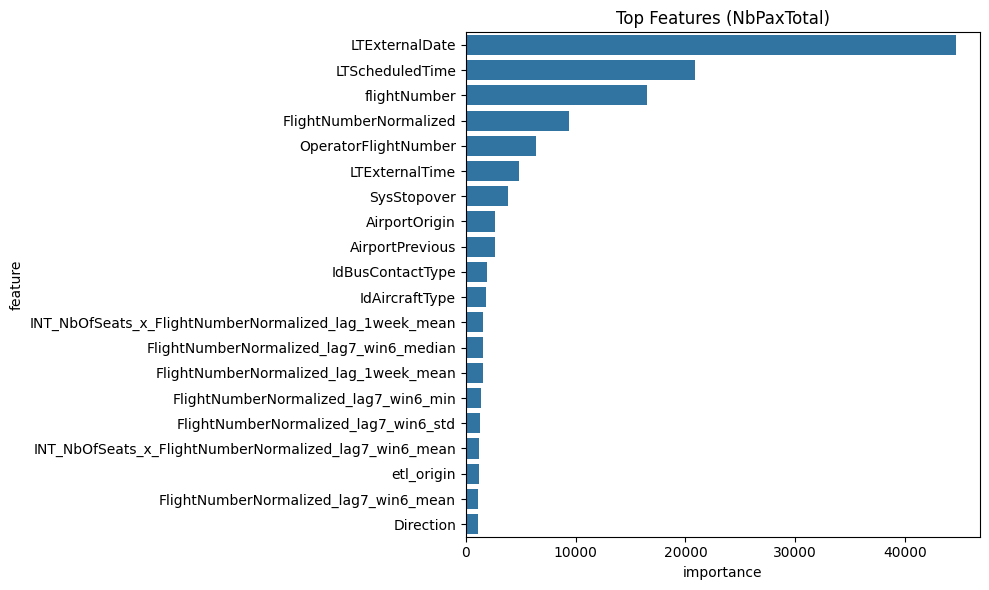

In [37]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_Pax.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.to_csv(os.path.join(DATA_FOLDER_PATH, "features_importances_Pax.csv"), index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance.head(20))
plt.title("Top Features (NbPaxTotal)")
plt.tight_layout()
plt.show()

#### 2. Prediction VS Reality

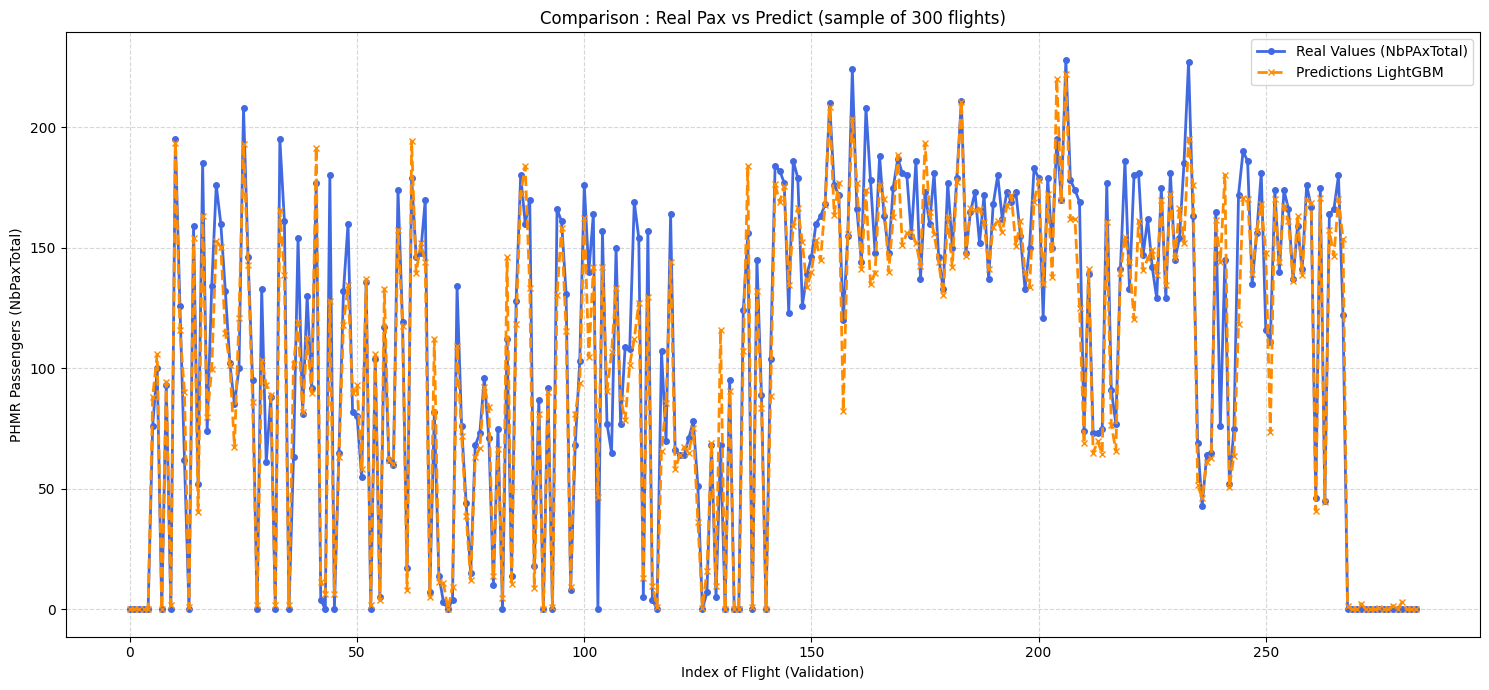

In [38]:
n_sample = 300 
plt.figure(figsize=(15, 7))
plt.plot(y_valid.values[:n_sample], label='Real Values (NbPAxTotal)', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions[:n_sample], label='Predictions LightGBM', color='darkorange', linestyle='--', linewidth=2, marker='x', markersize=5)
plt.title(f'Comparison : Real Pax vs Predict (sample of {n_sample} flights)')
plt.ylabel('PHMR Passengers (NbPaxTotal)')
plt.xlabel('Index of Flight (Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 3. TOP 10 Errors

In [41]:
analysis_df = valid_df.copy()
analysis_df['Predicted_NbPax'] = predictions
analysis_df['Abs_Error'] = np.abs(analysis_df[TARGET[0]] - analysis_df['Predicted_NbPax'])
top_errors = analysis_df.sort_values(by='Abs_Error', ascending=False).head(10)

def highlight_errors(df):
    
    # Columns to show
    columns = ["FlightNumberNormalized", "LTExternalDatetime", TARGET[0], 
               "Predicted_NbPax", "NbOfSeats", "Abs_Error"]
    
    # Rounding values
    display_df = df[columns].copy().head(10)
    display_df['Predicted_NbPax'] = display_df['Predicted_NbPax'].round(1)
    display_df['Abs_Error'] = display_df['Abs_Error'].round(1)
    
    # Style
    return display_df.style\
        .background_gradient(subset=['Abs_Error'], cmap='Reds')\
        .background_gradient(subset=[TARGET[0]], cmap='Blues')\
        .format({'LTScheduledDatetime': lambda x: x.strftime('%d/%m %H:%M')})\
        .set_caption("TOP 10 ERRORS")

highlight_errors(top_errors)

,FlightNumberNormalized,LTExternalDatetime,NbPaxTotal,Predicted_NbPax,NbOfSeats,Abs_Error
330297,EZY02432,2026-03-27 21:30:00,76.000000,144.200000,186.000000,68.200000
330278,TVF07328,2026-03-27 17:55:00,180.000000,120.300000,189.000000,59.700000
163622,SEH00925,2026-03-27 19:30:00,169.000000,112.200000,180.000000,56.800000
330301,TVF07313,2026-03-27 22:15:00,172.000000,118.200000,189.000000,53.800000
163555,AUA00353,2026-03-27 12:05:00,180.000000,128.000000,180.000000,52.000000
163641,BAW00363,2026-03-27 21:10:00,68.000000,116.000000,180.000000,48.000000
163614,VLJ00051,2026-03-27 18:35:00,0.000000,46.700000,50.000000,46.700000
330266,TVF07309,2026-03-27 17:00:00,169.000000,125.100000,189.000000,43.900000
330220,TVF09853,2026-03-27 10:20:00,178.000000,134.800000,189.000000,43.200000
163617,DLH01079,2026-03-27 19:00:00,65.000000,106.600000,138.000000,41.600000


### PHMR

#### 1. Feature importance

In [ ]:
importance = pd.DataFrame({
    "feature": X_train_PHMR.columns,
    "importance": model_PHMR.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.to_csv(os.path.join(DATA_FOLDER_PATH, "features_importances_PHMR.csv"), index=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance.head(20))
plt.title("Top Features (PHMR)")
plt.tight_layout()
plt.show()

#### 2. Prediction VS Reality

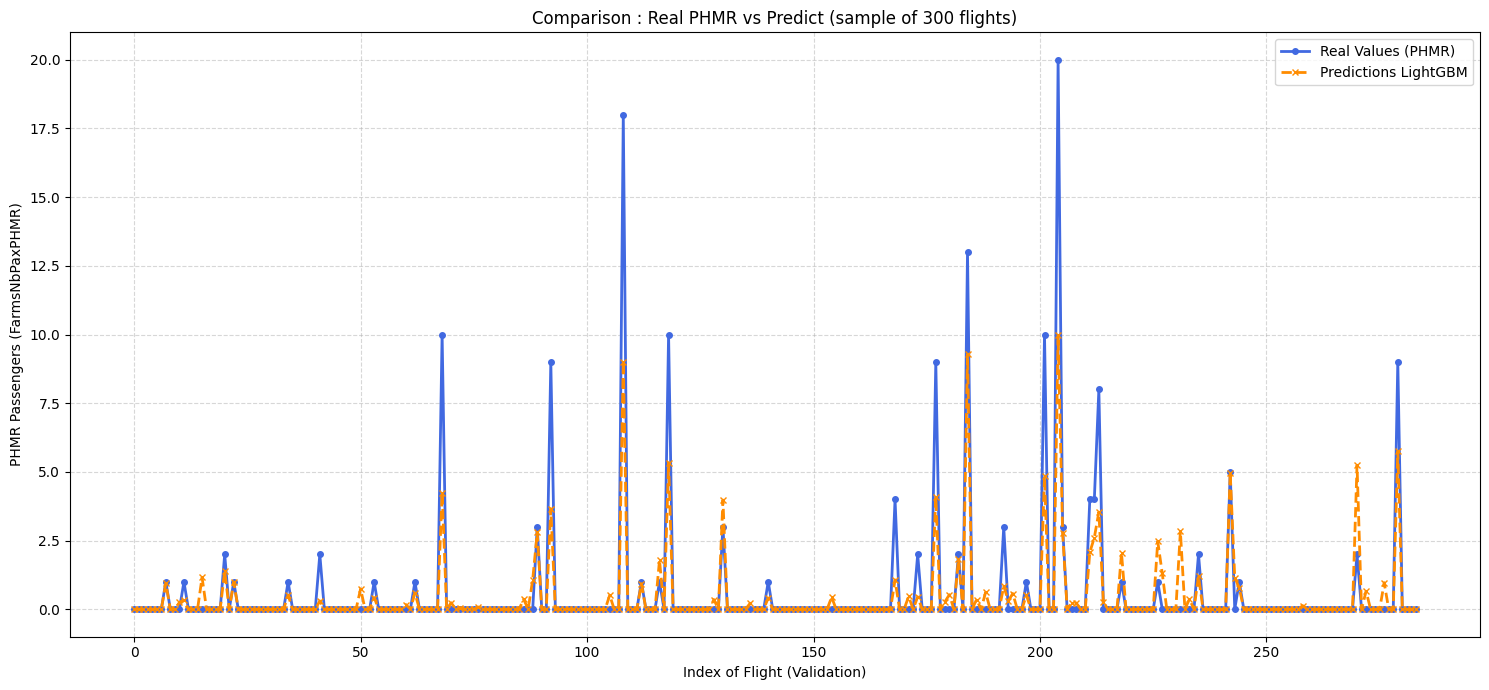

In [42]:
n_sample = 300 
plt.figure(figsize=(15, 7))
plt.plot(y_valid_PHMR.values[:n_sample], label='Real Values (PHMR)', color='royalblue', linewidth=2, marker='o', markersize=4)
plt.plot(predictions_PHMR[:n_sample], label='Predictions LightGBM', color='darkorange', linestyle='--', linewidth=2, marker='x', markersize=5)
plt.title(f'Comparison : Real PHMR vs Predict (sample of {n_sample} flights)')
plt.ylabel('PHMR Passengers (FarmsNbPaxPHMR)')
plt.xlabel('Index of Flight (Validation)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 3. TOP 10 Errors

In [44]:
analysis_df = valid_df_PHMR.copy()
analysis_df['Predicted_PHMR'] = predictions_PHMR
analysis_df['Abs_Error'] = np.abs(analysis_df[TARGET[1]] - analysis_df['Predicted_PHMR'])
top_errors = analysis_df.sort_values(by='Abs_Error', ascending=False).head(10)

def highlight_errors(df):
    
    # Columns to show
    columns = ["FlightNumberNormalized", "LTExternalDatetime", TARGET[1], 
               "Predicted_PHMR", "NbOfSeats", "Abs_Error"]
    
    # Rounding values
    display_df = df[columns].copy().head(10)
    display_df['Predicted_PHMR'] = display_df['Predicted_PHMR'].round(1)
    display_df['Abs_Error'] = display_df['Abs_Error'].round(1)
    
    # Style
    return display_df.style\
        .background_gradient(subset=['Abs_Error'], cmap='Reds')\
        .background_gradient(subset=[TARGET[1]], cmap='Blues')\
        .format({'LTScheduledDatetime': lambda x: x.strftime('%d/%m %H:%M')})\
        .set_caption("TOP 10 ERRORS")

highlight_errors(top_errors)

,FlightNumberNormalized,LTExternalDatetime,FarmsNbPaxPHMR,Predicted_PHMR,NbOfSeats,Abs_Error
56061,DAH01139,2026-03-27 11:50:00,20.000000,10.000000,144.000000,10.000000
55965,DAH01461,2026-03-27 17:20:00,18.000000,9.000000,144.000000,9.000000
55925,DAH01033,2026-03-27 19:05:00,10.000000,4.200000,180.000000,5.800000
55949,TVF07328,2026-03-27 17:55:00,9.000000,3.700000,189.000000,5.300000
56058,TVF07308,2026-03-27 12:00:00,10.000000,4.800000,189.000000,5.200000
56034,PGT01142,2026-03-27 12:55:00,9.000000,4.100000,239.000000,4.900000
55975,TVF07312,2026-03-27 16:50:00,10.000000,5.300000,189.000000,4.700000
56070,TVF09852,2026-03-27 11:15:00,8.000000,3.500000,189.000000,4.500000
56041,DAH01037,2026-03-27 12:35:00,13.000000,9.300000,180.000000,3.700000
56136,TVF08704,2026-03-27 06:00:00,9.000000,5.700000,189.000000,3.300000
